--- 因子工厂启动 ---
正在读取数据: C:\Fama_French_Project\data\cleaned_ff_data.csv ...
数据加载完成，共 472402 行。

正在进行缩尾处理 (Winsorize BM at 1% / 99%)...
缩尾清洗后剩余数据: 471645 行。

正在构建因子 (按月切分 2x3 组合)...
因子计算完成！

因子数据已保存至: C:\Fama_French_Project\data\ff3_factors_final.csv

正在生成图表...
高清图表已保存至: C:\Fama_French_Project\ff3_cumulative_returns.png


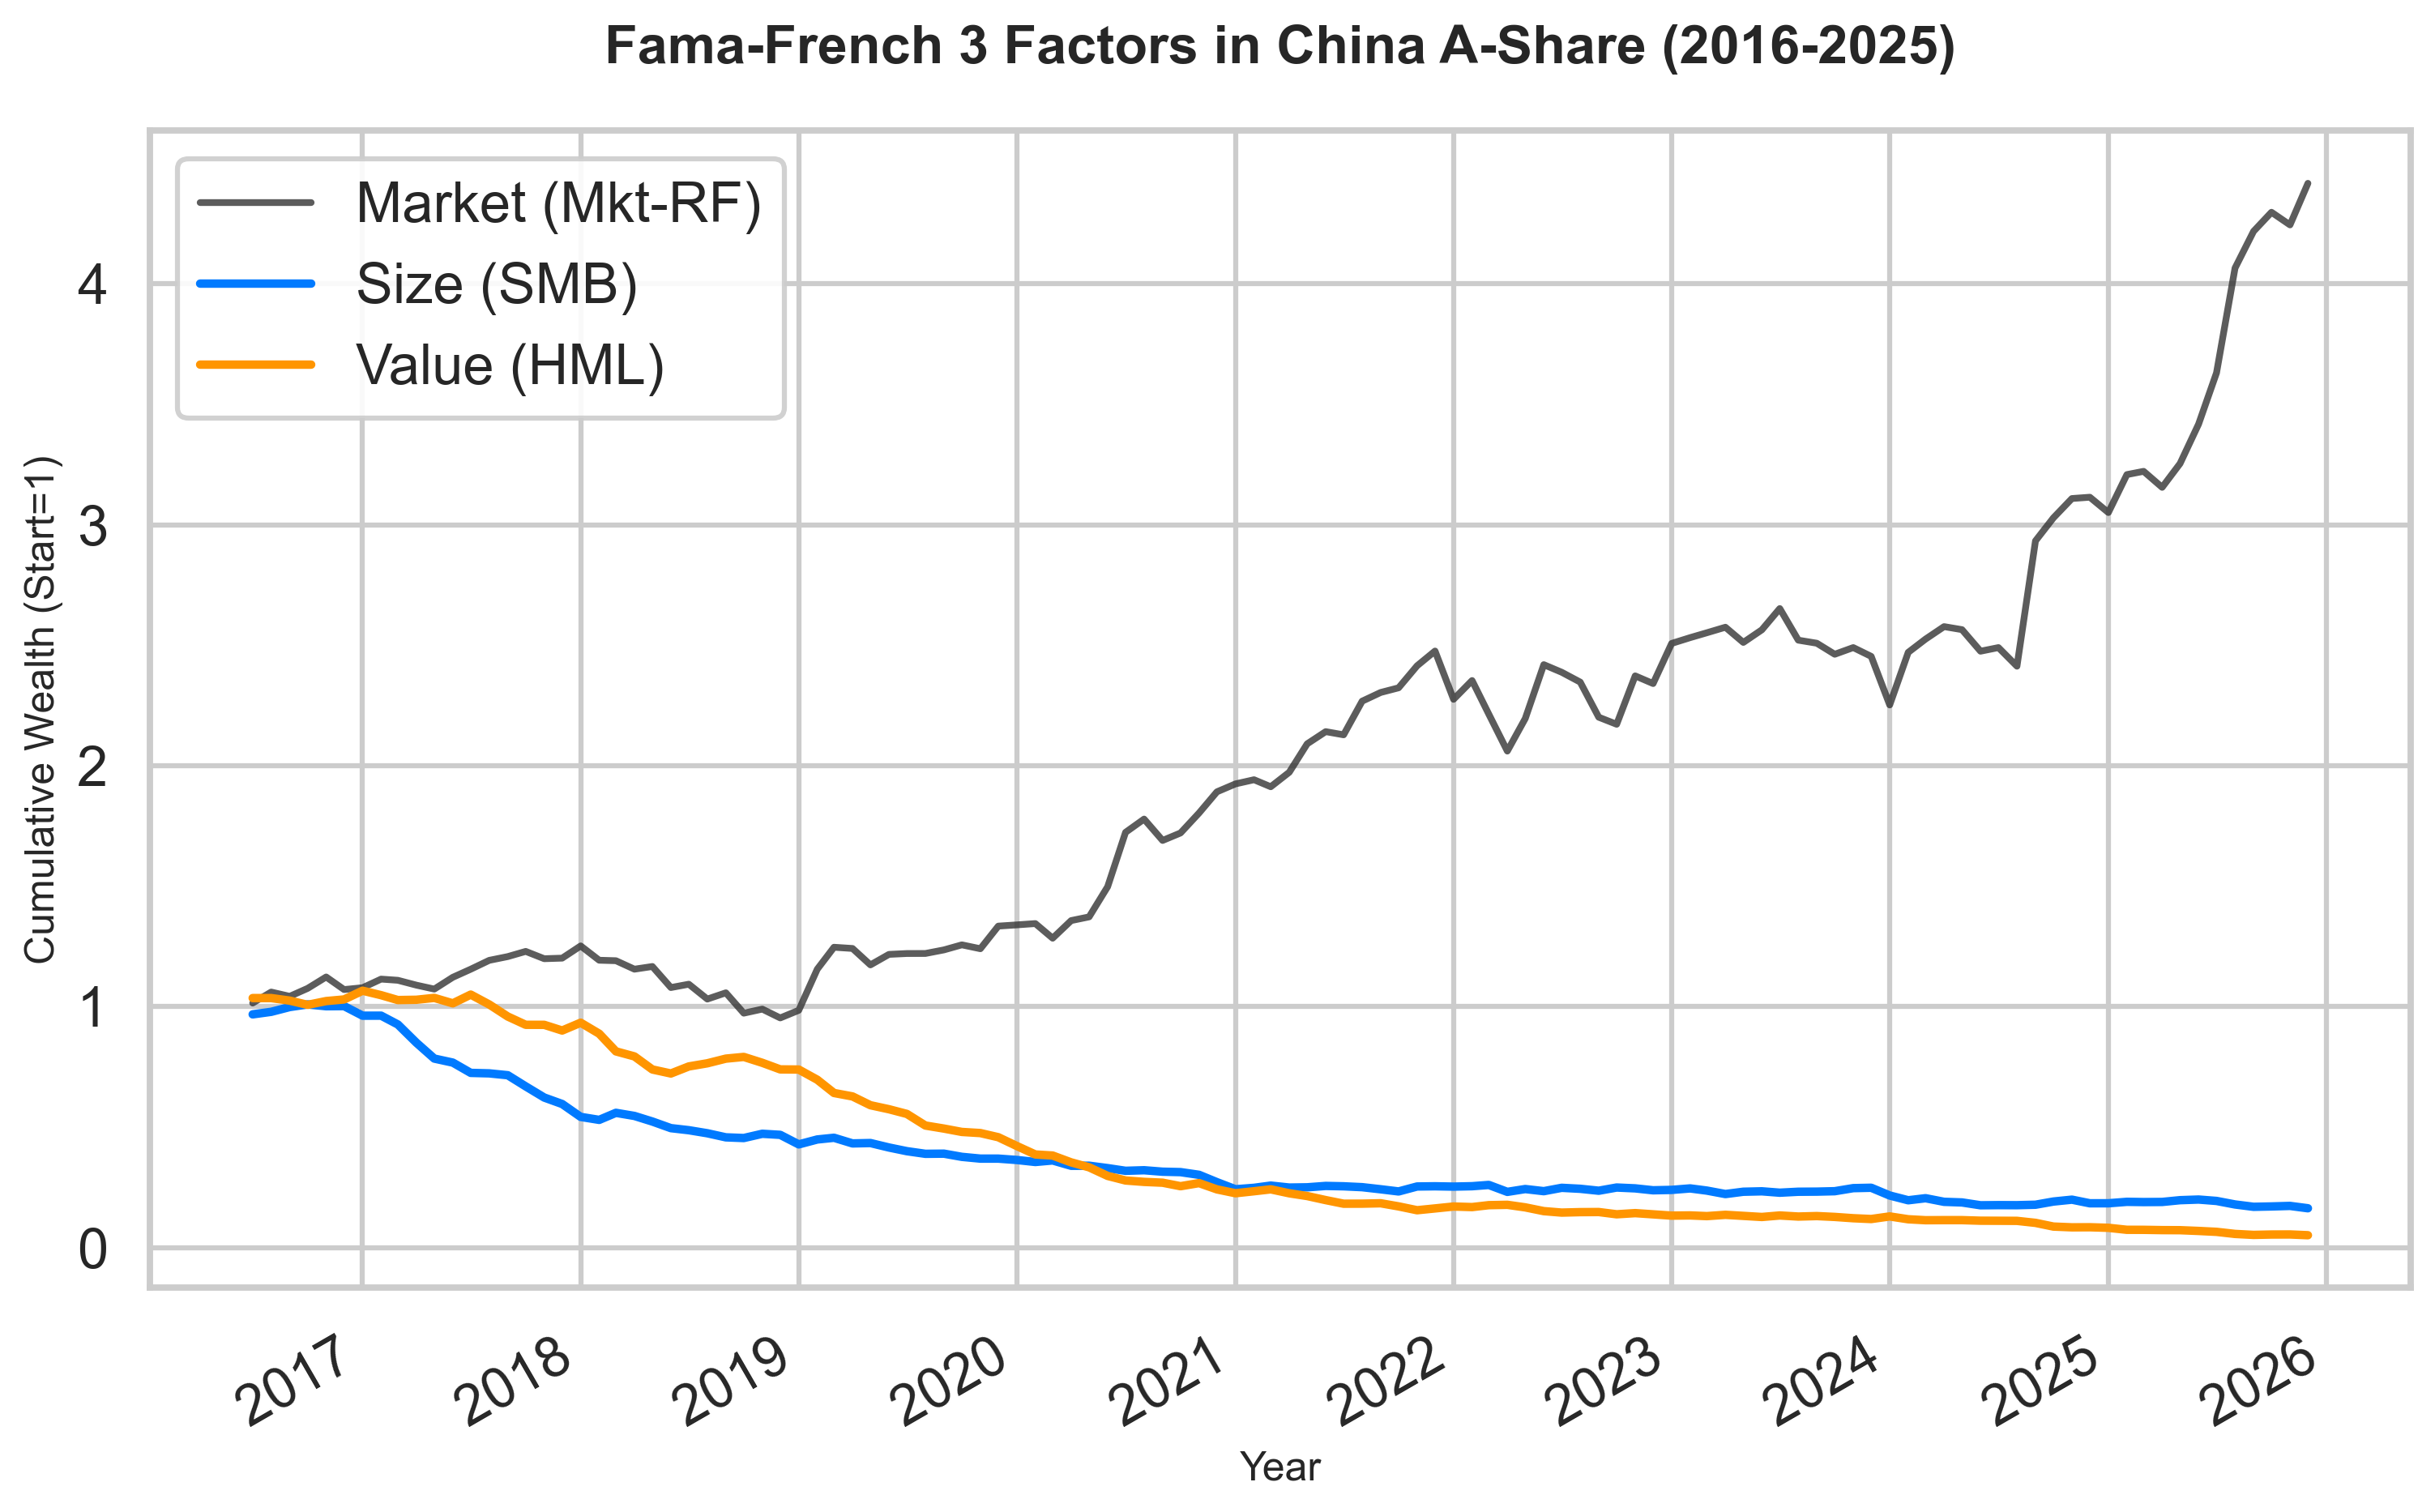


--- 因子描述性统计 (Monthly) ---
           Mkt_RF         SMB         HML
count  114.000000  114.000000  114.000000
mean     0.014259   -0.014913   -0.024752
std      0.048938    0.041279    0.043393
min     -0.082171   -0.129478   -0.149681
25%     -0.014352   -0.036823   -0.056467
50%      0.011749   -0.012061   -0.025290
75%      0.034416    0.008484    0.003720
max      0.215563    0.088248    0.090683


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# --- Step 0: 环境与路径 (保持与清洗步骤一致) ---
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# 绝对路径
PROJECT_FOLDER_PATH = r"C:\Fama_French_Project"
DATA_PATH = os.path.join(PROJECT_FOLDER_PATH, 'data', 'cleaned_ff_data.csv')
OUTPUT_FACTOR_PATH = os.path.join(PROJECT_FOLDER_PATH, 'data', 'ff3_factors_final.csv')
IMG_PATH = os.path.join(PROJECT_FOLDER_PATH, 'ff3_cumulative_returns.png')

print("--- 因子工厂启动 ---")

# --- Step 1: 读取清洗好的数据 ---
print(f"正在读取数据: {DATA_PATH} ...")
df = pd.read_csv(DATA_PATH)
df['trd_month'] = pd.to_datetime(df['trd_month'])
print(f"数据加载完成，共 {len(df)} 行。")


# --- Step 2: 缩尾处理 (Winsorization) ---
# 【关键改进】剔除 BM 极高/极低的垃圾股，防止因子被噪音扭曲
print("\n正在进行缩尾处理 (Winsorize BM at 1% / 99%)...")

def winsorize_series(s):
    # 仅对 BM 进行缩尾
    lower = s.quantile(0.01)
    upper = s.quantile(0.99)
    return s.clip(lower, upper)

# 按月分组进行缩尾 (更严谨的做法)
df['BM'] = df.groupby('trd_month')['BM'].transform(winsorize_series)

# 再次剔除极端异常值 (双重保险)
# A股正常 BM 很少超过 20 (市净率 < 0.05) 或小于 0.01 (市净率 > 100)
df = df[(df['BM'] > 0.01) & (df['BM'] < 20)]
print(f"缩尾清洗后剩余数据: {len(df)} 行。")


# --- Step 3: Fama-French 2x3 分组核心逻辑 ---
print("\n正在构建因子 (按月切分 2x3 组合)...")

def construct_factors(group):
    """
    输入：某一个月的截面数据 (所有股票)
    输出：该月的 Mkt, SMB, HML 因子收益率
    """
    if len(group) < 10: # 如果该月数据太少，跳过
        return None
        
    # 1. 确定断点 (Breakpoints)
    # Size: 中位数
    size_median = group['me'].median()
    # BM: 30%, 70% 分位数
    bm_30 = group['BM'].quantile(0.3)
    bm_70 = group['BM'].quantile(0.7)
    
    # 2. 划分 Size 组 (S, B)
    # 小盘股 (S), 大盘股 (B)
    s_mask = group['me'] < size_median
    b_mask = group['me'] >= size_median
    
    # 3. 划分 Value 组 (L, M, H)
    # 成长 (L), 中性 (M), 价值 (H)
    l_mask = group['BM'] <= bm_30
    h_mask = group['BM'] >= bm_70
    m_mask = (~l_mask) & (~h_mask)
    
    # 4. 构建 6 个基础组合的加权收益率
    # 定义计算加权平均的辅助函数
    def get_wavg_ret(mask):
        sub_df = group[mask]
        if len(sub_df) == 0: return 0.0
        return np.average(sub_df['ret'], weights=sub_df['me'])

    # 交叉组合：SL, SM, SH, BL, BM, BH
    r_sl = get_wavg_ret(s_mask & l_mask)
    r_sm = get_wavg_ret(s_mask & m_mask)
    r_sh = get_wavg_ret(s_mask & h_mask)
    
    r_bl = get_wavg_ret(b_mask & l_mask)
    r_bm = get_wavg_ret(b_mask & m_mask)
    r_bh = get_wavg_ret(b_mask & h_mask)
    
    # 5. 计算因子
    # SMB = (Small 3组均值) - (Big 3组均值)
    smb = (r_sl + r_sm + r_sh) / 3 - (r_bl + r_bm + r_bh) / 3
    
    # HML = (High 2组均值) - (Low 2组均值) -> (价值 - 成长)
    hml = (r_sh + r_bh) / 2 - (r_sl + r_bl) / 2
    
    # Mkt = 全市场加权平均 - 无风险利率
    mkt_ret = np.average(group['ret'], weights=group['me'])
    rf = group['rf'].iloc[0]
    mkt_rf = mkt_ret - rf
    
    return pd.Series({
        'Mkt_RF': mkt_rf,
        'SMB': smb,
        'HML': hml,
        'RF': rf
    })

# 执行 Groupby Apply
df_factors = df.groupby('trd_month').apply(construct_factors).reset_index()
print("因子计算完成！")


# --- Step 4: 结果检验与可视化 (Apple Style) ---

# 4.1 计算累积收益 (用于画图)
df_factors['Cum_Mkt'] = (1 + df_factors['Mkt_RF']).cumprod()
df_factors['Cum_SMB'] = (1 + df_factors['SMB']).cumprod()
df_factors['Cum_HML'] = (1 + df_factors['HML']).cumprod()

# 4.2 保存因子文件
df_factors.to_csv(OUTPUT_FACTOR_PATH, index=False)
print(f"\n因子数据已保存至: {OUTPUT_FACTOR_PATH}")

# 4.3 画图
print("\n正在生成图表...")
sns.set_theme(style="whitegrid", context="talk") # 设置为学术风格
plt.figure(figsize=(12, 7), dpi=300)

# 绘制三条线
plt.plot(df_factors['trd_month'], df_factors['Cum_Mkt'], 
         label='Market (Mkt-RF)', color='#333333', linewidth=2, alpha=0.8)
plt.plot(df_factors['trd_month'], df_factors['Cum_SMB'], 
         label='Size (SMB)', color='#007AFF', linewidth=2.5) # 苹果蓝
plt.plot(df_factors['trd_month'], df_factors['Cum_HML'], 
         label='Value (HML)', color='#FF9500', linewidth=2.5) # 苹果橙

# 标注
plt.title('Fama-French 3 Factors in China A-Share (2016-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Cumulative Wealth (Start=1)', fontsize=12)
plt.legend(frameon=True, fancybox=True, framealpha=0.9, loc='upper left')

# 微调 X 轴日期显示
plt.gcf().autofmt_xdate()

# 保存
plt.savefig(IMG_PATH, bbox_inches='tight')
print(f"高清图表已保存至: {IMG_PATH}")

plt.show()

# 4.4 打印描述性统计 (用于写报告)
print("\n--- 因子描述性统计 (Monthly) ---")
print(df_factors[['Mkt_RF', 'SMB', 'HML']].describe())

正在启动 C计划：调用 AkShare 下载基准指数...
正在下载 HS300 (Value) (sh000300)...
正在下载 ChiNext (Growth) (sz399006)...

--- 终极审判：因子相关性检查 ---
                  HS300 (Value)  ChiNext (Growth)    My_HML
HS300 (Value)          1.000000          0.795632 -0.230761
ChiNext (Growth)       0.795632          1.000000 -0.639782
My_HML                -0.230761         -0.639782  1.000000


<Figure size 1200x600 with 0 Axes>

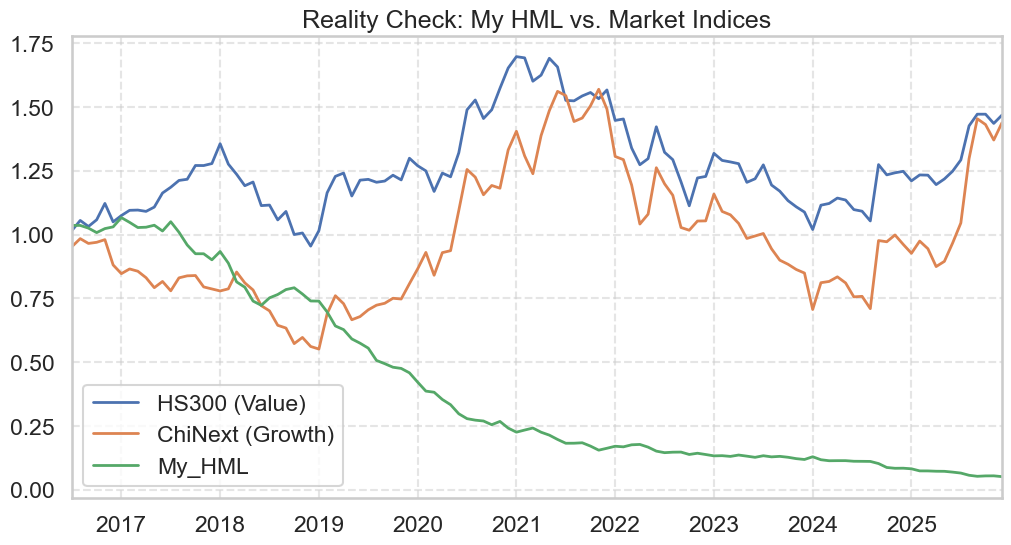

In [20]:
import akshare as ak
import pandas as pd
import matplotlib.pyplot as plt

print("正在启动 C计划：调用 AkShare 下载基准指数...")

def get_index_monthly_return(symbol, name):
    print(f"正在下载 {name} ({symbol})...")
    # AkShare 获取指数历史行情
    df = ak.stock_zh_index_daily(symbol=symbol)
    
    # 清洗数据
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()
    
    # 筛选时间
    df = df['2016-01-01':'2025-12-31']
    
    # 转为月度收益率 (取每月最后一天收盘价计算)
    df_monthly = df['close'].resample('M').last().pct_change()
    df_monthly.name = name
    return df_monthly

try:
    # 1. 下载沪深300 (sh000300) -> 代表大盘价值
    hs300 = get_index_monthly_return("sh000300", "HS300 (Value)")
    
    # 2. 下载创业板指 (sz399006) -> 代表小盘成长
    chinext = get_index_monthly_return("sz399006", "ChiNext (Growth)")
    
    # 3. 准备你的 HML 数据
    # 确保 df_factors 在内存里
    # 注意：你的 df_factors['trd_month'] 可能是 datetime 或 period，统一转为 PeriodIndex
    my_hml = df_factors.copy()
    if 'trd_month' in my_hml.columns:
        my_hml = my_hml.set_index('trd_month')
    
    # 确保索引格式一致 (Period[M])
    my_hml.index = pd.to_datetime(my_hml.index.astype(str)).to_period('M')
    hs300.index = hs300.index.to_period('M')
    chinext.index = chinext.index.to_period('M')
    
    # 4. 合并数据
    comparison = pd.concat([hs300, chinext, my_hml['HML']], axis=1).dropna()
    comparison.columns = ['HS300 (Value)', 'ChiNext (Growth)', 'My_HML']

    # 5. 计算相关性
    print("\n--- 终极审判：因子相关性检查 ---")
    corr_matrix = comparison.corr()
    print(corr_matrix)

    # 6. 画图验证 (重点看2021年后)
    plt.figure(figsize=(12, 6))
    (1 + comparison).cumprod().plot(figsize=(12, 6), linewidth=2)
    plt.title("Reality Check: My HML vs. Market Indices")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

except Exception as e:
    print(f"出错了: {e}")
    print("请确保你已经安装了 akshare: pip install akshare")